# Phase 2A. Pooled Spatial Generalization

Multi-year pooled XGBoost model using the combined 2022–2025 gold table. Exports summary tables and paper-ready figures.

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

GOLD_PATH = r"..\..\..\Data\c_final_tables\baseline_model_gold_table\I66_phase1_TTI_features_2022_2025_combined.parquet"
OUTPUT_DIR = r"..\..\..\notebooks\modelling\project_1_output\phase2_pooled_2022_2025"

os.makedirs(OUTPUT_DIR, exist_ok=True)

target_column = "target_tti_30min_ahead"   # change if you want 5min or 15min
train_end_date = "2024-12-31 23:59:59+00:00"
validation_end_date = "2025-06-30 23:59:59+00:00"

xgboost_parameters = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
}


In [3]:

gold_dataframe = pd.read_parquet(GOLD_PATH).copy()
gold_dataframe["ts_utc"] = pd.to_datetime(gold_dataframe["ts_utc"], utc=True)
gold_dataframe = gold_dataframe[gold_dataframe["ts_local"].dt.year <= 2025].copy()
gold_dataframe = gold_dataframe.sort_values(["tmc", "direction", "ts_utc"]).reset_index(drop=True)

# create cyclical calendar features if missing
if "sin_hour" not in gold_dataframe.columns or "cos_hour" not in gold_dataframe.columns:
    gold_dataframe["hour"] = gold_dataframe["ts_utc"].dt.hour
    gold_dataframe["sin_hour"] = np.sin(2 * np.pi * gold_dataframe["hour"] / 24)
    gold_dataframe["cos_hour"] = np.cos(2 * np.pi * gold_dataframe["hour"] / 24)

if "sin_day_of_week" not in gold_dataframe.columns or "cos_day_of_week" not in gold_dataframe.columns:
    gold_dataframe["day_of_week"] = gold_dataframe["ts_utc"].dt.dayofweek
    gold_dataframe["sin_day_of_week"] = np.sin(2 * np.pi * gold_dataframe["day_of_week"] / 7)
    gold_dataframe["cos_day_of_week"] = np.cos(2 * np.pi * gold_dataframe["day_of_week"] / 7)

if "sin_month" not in gold_dataframe.columns or "cos_month" not in gold_dataframe.columns:
    gold_dataframe["month"] = gold_dataframe["ts_utc"].dt.month
    gold_dataframe["sin_month"] = np.sin(2 * np.pi * (gold_dataframe["month"] - 1) / 12)
    gold_dataframe["cos_month"] = np.cos(2 * np.pi * (gold_dataframe["month"] - 1) / 12)

if "is_weekend_flag" not in gold_dataframe.columns:
    gold_dataframe["is_weekend_flag"] = (gold_dataframe["ts_utc"].dt.dayofweek >= 5).astype(int)

gold_dataframe["tmc_encoded"] = gold_dataframe["tmc"].astype("category").cat.codes

feature_columns = [
    col for col in gold_dataframe.columns
    if col.startswith("tti_lag_")
    or col.startswith("tti_rolling_")
    or col in [
        "tti_change_1_step",
        "tti_absolute_change_1_step",
        "is_low_confidence_flag",
        "sin_hour",
        "cos_hour",
        "sin_day_of_week",
        "cos_day_of_week",
        "sin_month",
        "cos_month",
        "is_weekend_flag",
    ]
]

feature_columns_with_tmc = feature_columns + ["tmc_encoded"]

gold_dataframe = gold_dataframe.dropna(subset=[target_column]).copy()
gold_dataframe = gold_dataframe.dropna(subset=feature_columns_with_tmc).copy()

gold_dataframe["calendar_year"] = gold_dataframe["ts_utc"].dt.year

print(gold_dataframe.shape)
print("Number of TMC-direction groups:", gold_dataframe[["tmc", "direction"]].drop_duplicates().shape[0])
print("Target:", target_column)


(17229104, 46)
Number of TMC-direction groups: 41
Target: target_tti_30min_ahead


In [4]:

def calculate_regression_metrics(true_values, predicted_values):
    mae_value = mean_absolute_error(true_values, predicted_values)
    rmse_value = np.sqrt(mean_squared_error(true_values, predicted_values))
    return {"mae": float(mae_value), "rmse": float(rmse_value)}

def train_xgboost_regressor(training_features, training_target, model_parameters):
    model = XGBRegressor(**model_parameters)
    model.fit(training_features, training_target)
    return model


In [5]:

train_dataframe = gold_dataframe[gold_dataframe["ts_utc"] <= train_end_date].copy()
validation_dataframe = gold_dataframe[
    (gold_dataframe["ts_utc"] > train_end_date) &
    (gold_dataframe["ts_utc"] <= validation_end_date)
].copy()
test_dataframe = gold_dataframe[gold_dataframe["ts_utc"] > validation_end_date].copy()

print(len(train_dataframe), len(validation_dataframe), len(test_dataframe))

X_train = train_dataframe[feature_columns_with_tmc]
y_train = train_dataframe[target_column]

X_validation = validation_dataframe[feature_columns_with_tmc]
y_validation = validation_dataframe[target_column]

X_test = test_dataframe[feature_columns_with_tmc]
y_test = test_dataframe[target_column]

# persistence
validation_persistence_predictions = validation_dataframe["tti"].to_numpy()
test_persistence_predictions = test_dataframe["tti"].to_numpy()

validation_persistence_metrics = calculate_regression_metrics(y_validation, validation_persistence_predictions)
test_persistence_metrics = calculate_regression_metrics(y_test, test_persistence_predictions)

# pooled xgb
pooled_model = train_xgboost_regressor(X_train, y_train, xgboost_parameters)

validation_xgb_predictions = pooled_model.predict(X_validation)
test_xgb_predictions = pooled_model.predict(X_test)

validation_xgb_metrics = calculate_regression_metrics(y_validation, validation_xgb_predictions)
test_xgb_metrics = calculate_regression_metrics(y_test, test_xgb_predictions)

overall_results = pd.DataFrame([
    {
        "horizon": target_column.replace("target_tti_", "").replace("_ahead", ""),
        "model": "Persistence",
        "train_rows": len(train_dataframe),
        "validation_rows": len(validation_dataframe),
        "test_rows": len(test_dataframe),
        "validation_mae": validation_persistence_metrics["mae"],
        "validation_rmse": validation_persistence_metrics["rmse"],
        "test_mae": test_persistence_metrics["mae"],
        "test_rmse": test_persistence_metrics["rmse"],
    },
    {
        "horizon": target_column.replace("target_tti_", "").replace("_ahead", ""),
        "model": "XGBoost",
        "train_rows": len(train_dataframe),
        "validation_rows": len(validation_dataframe),
        "test_rows": len(test_dataframe),
        "validation_mae": validation_xgb_metrics["mae"],
        "validation_rmse": validation_xgb_metrics["rmse"],
        "test_mae": test_xgb_metrics["mae"],
        "test_rmse": test_xgb_metrics["rmse"],
    }
])

overall_results["mae_improvement_vs_persistence"] = np.where(
    overall_results["model"] == "Persistence",
    0.0,
    test_persistence_metrics["mae"] - overall_results["test_mae"],
)
overall_results


12920705 2136489 2171910


,horizon,model,train_rows,validation_rows,test_rows,validation_mae,validation_rmse,test_mae,test_rmse,mae_improvement_vs_persistence
0,30min,Persistence,12920705,2136489,2171910,0.156121,0.489694,0.149337,0.477489,0.000000
1,30min,XGBoost,12920705,2136489,2171910,0.139001,0.410259,0.134220,0.403017,0.015117


In [6]:

test_predictions_dataframe = test_dataframe[[
    "tmc", "direction", "ts_utc", "calendar_year", "tti", target_column
]].copy()
test_predictions_dataframe["persistence_prediction"] = test_persistence_predictions
test_predictions_dataframe["xgb_prediction"] = test_xgb_predictions

per_tmc_results = (
    test_predictions_dataframe
    .groupby(["tmc", "direction"], as_index=False)
    .apply(
        lambda df: pd.Series({
            "test_rows": len(df),
            "mae_persistence": mean_absolute_error(df[target_column], df["persistence_prediction"]),
            "rmse_persistence": np.sqrt(mean_squared_error(df[target_column], df["persistence_prediction"])),
            "mae_pooled_xgb": mean_absolute_error(df[target_column], df["xgb_prediction"]),
            "rmse_pooled_xgb": np.sqrt(mean_squared_error(df[target_column], df["xgb_prediction"])),
        })
    )
    .reset_index(drop=True)
)

per_tmc_results["mae_improvement_pooled_xgb"] = (
    per_tmc_results["mae_persistence"] - per_tmc_results["mae_pooled_xgb"]
)
per_tmc_results["rmse_improvement_pooled_xgb"] = (
    per_tmc_results["rmse_persistence"] - per_tmc_results["rmse_pooled_xgb"]
)

per_tmc_results.head()


,tmc,direction,test_rows,mae_persistence,rmse_persistence,mae_pooled_xgb,rmse_pooled_xgb,mae_improvement_pooled_xgb,rmse_improvement_pooled_xgb
0,110+04164,WESTBOUND,52911.0,0.073712,0.201266,0.068843,0.242258,0.004868,-0.040992
1,110+04165,WESTBOUND,52911.0,0.092874,0.330882,0.080560,0.293340,0.012314,0.037542
2,110+04166,WESTBOUND,52964.0,0.194072,0.592145,0.164842,0.473110,0.029230,0.119035
3,110+04167,WESTBOUND,52988.0,0.233482,0.575644,0.206909,0.501753,0.026573,0.073890
4,110+04168,WESTBOUND,52972.0,0.214558,0.775651,0.192557,0.632711,0.022001,0.142940


In [7]:

per_year_results = (
    test_predictions_dataframe
    .groupby(["calendar_year"], as_index=False)
    .apply(
        lambda df: pd.Series({
            "test_rows": len(df),
            "mae_persistence": mean_absolute_error(df[target_column], df["persistence_prediction"]),
            "rmse_persistence": np.sqrt(mean_squared_error(df[target_column], df["persistence_prediction"])),
            "mae_pooled_xgb": mean_absolute_error(df[target_column], df["xgb_prediction"]),
            "rmse_pooled_xgb": np.sqrt(mean_squared_error(df[target_column], df["xgb_prediction"])),
        })
    )
    .reset_index(drop=True)
)

per_year_results["mae_improvement_pooled_xgb"] = (
    per_year_results["mae_persistence"] - per_year_results["mae_pooled_xgb"]
)
per_year_results


,calendar_year,test_rows,mae_persistence,rmse_persistence,mae_pooled_xgb,rmse_pooled_xgb,mae_improvement_pooled_xgb
0,2025,2169696.0,0.149452,0.477730,0.134322,0.403221,0.015130
1,2026,2214.0,0.036932,0.048055,0.034920,0.044240,0.002011


In [8]:

train_subset = gold_dataframe[gold_dataframe["ts_utc"] <= train_end_date].copy()

volatility_results = (
    train_subset
    .groupby(["tmc", "direction"], as_index=False)["tti"]
    .std()
    .rename(columns={"tti": "tti_volatility"})
)

volatility_results = volatility_results.merge(per_tmc_results, on=["tmc", "direction"], how="inner")
volatility_correlation = volatility_results[["tti_volatility", "mae_pooled_xgb"]].corr()
volatility_correlation


,tti_volatility,mae_pooled_xgb
tti_volatility,1.000000,0.789628
mae_pooled_xgb,0.789628,1.000000


In [10]:

overall_results.to_csv(os.path.join(OUTPUT_DIR, "pooled_overall_results.csv"), index=False)
per_tmc_results.to_csv(os.path.join(OUTPUT_DIR, "pooled_per_tmc_results.csv"), index=False)
per_year_results.to_csv(os.path.join(OUTPUT_DIR, "pooled_per_year_results.csv"), index=False)
volatility_results.to_csv(os.path.join(OUTPUT_DIR, "pooled_volatility_results.csv"), index=False)

paper_summary_table = overall_results[[
    "horizon", "model", "validation_mae", "validation_rmse", "test_mae", "test_rmse", "mae_improvement_vs_persistence"
]].copy()
paper_summary_table.to_csv(os.path.join(OUTPUT_DIR, "pooled_paper_summary_table.csv"), index=False)

print("Saved CSV files to:", OUTPUT_DIR)


Saved CSV files to: ..\..\..\notebooks\modelling\model_outputs\Phase_1_model\phase2_pooled_2022_2025


## Paper-ready figures

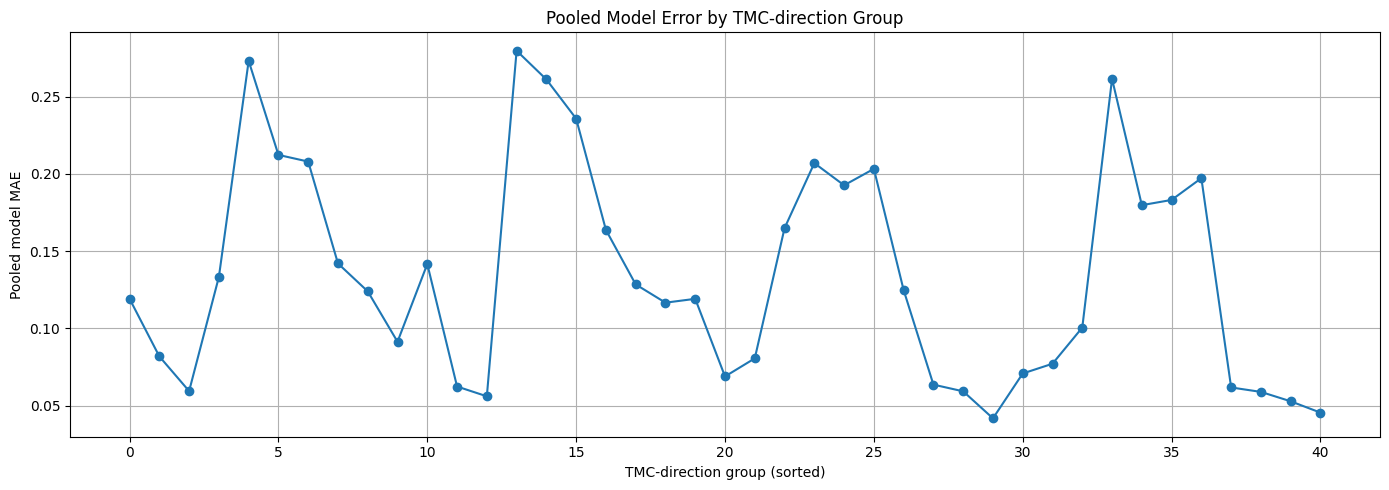

In [11]:

# Figure 1. Pooled MAE by TMC-direction
plot_dataframe = per_tmc_results.sort_values(["direction", "tmc"]).reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(plot_dataframe.index, plot_dataframe["mae_pooled_xgb"], marker="o")
plt.xlabel("TMC-direction group (sorted)")
plt.ylabel("Pooled model MAE")
plt.title("Pooled Model Error by TMC-direction Group")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_pooled_mae_by_tmc.png"), dpi=300, bbox_inches="tight")
plt.show()


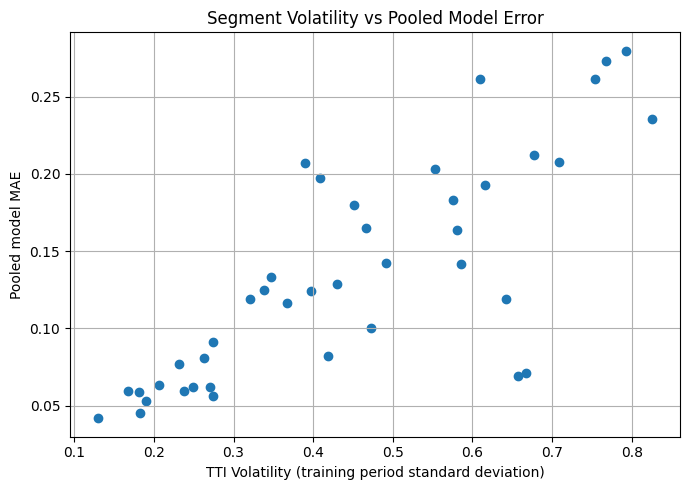

In [12]:

# Figure 2. Volatility vs pooled MAE
plt.figure(figsize=(7, 5))
plt.scatter(volatility_results["tti_volatility"], volatility_results["mae_pooled_xgb"])
plt.xlabel("TTI Volatility (training period standard deviation)")
plt.ylabel("Pooled model MAE")
plt.title("Segment Volatility vs Pooled Model Error")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_pooled_volatility_vs_mae.png"), dpi=300, bbox_inches="tight")
plt.show()


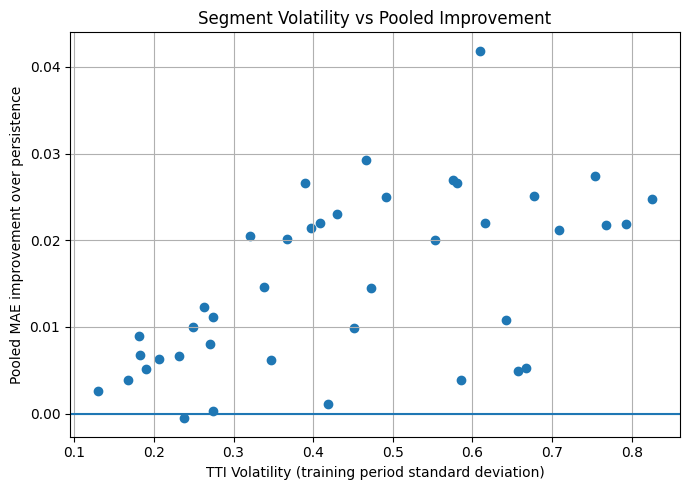

In [13]:
# Figure 3. Volatility vs Pooled improvement
plt.figure(figsize=(7, 5))
plt.scatter(volatility_results["tti_volatility"], volatility_results["mae_improvement_pooled_xgb"])
plt.axhline(0)
plt.xlabel("TTI Volatility (training period standard deviation)")
plt.ylabel("Pooled MAE improvement over persistence")
plt.title("Segment Volatility vs Pooled Improvement")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_pooled_volatility_vs_improvement.png"), dpi=300, bbox_inches="tight")
plt.show()

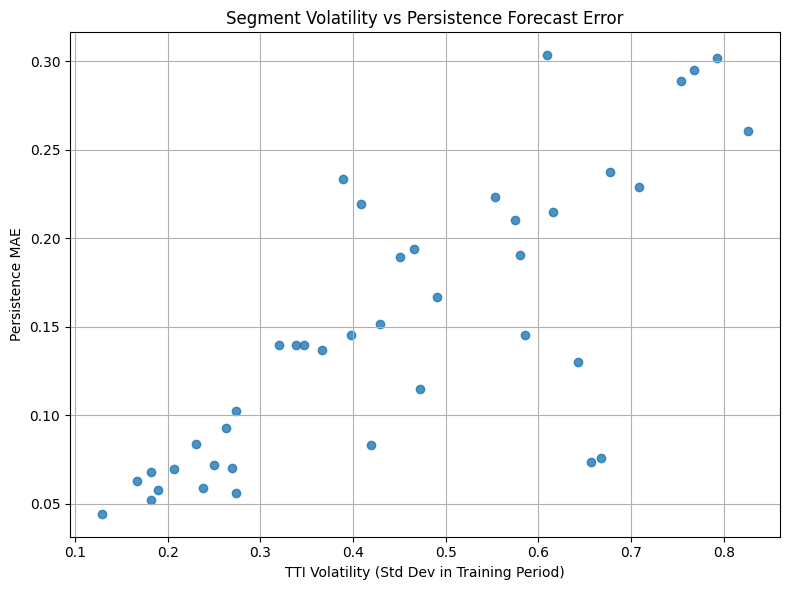

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(volatility_results["tti_volatility"],
            volatility_results["mae_persistence"],
            alpha=0.8)

plt.xlabel("TTI Volatility (Std Dev in Training Period)")
plt.ylabel("Persistence MAE")
plt.title("Segment Volatility vs Persistence Forecast Error")

plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_pooled_volatility_vs_mae_persistence.png"), dpi=300, bbox_inches="tight")
plt.show()

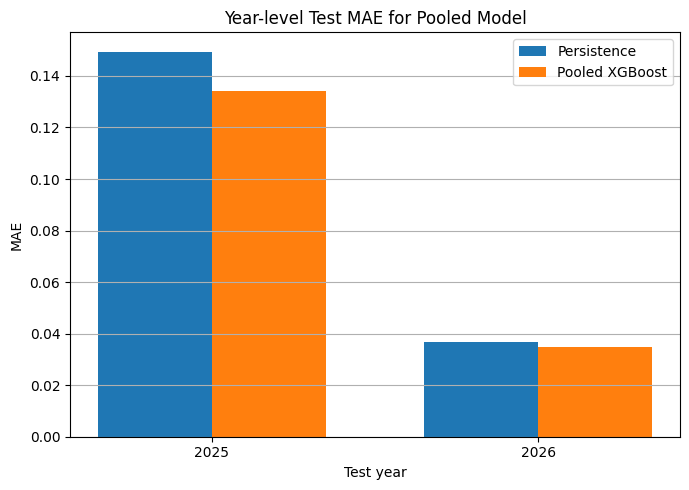

In [15]:

# Figure 3. Year-level pooled performance comparison
plot_year = per_year_results.copy()

x_positions = np.arange(len(plot_year))
bar_width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x_positions - bar_width / 2, plot_year["mae_persistence"], width=bar_width, label="Persistence")
plt.bar(x_positions + bar_width / 2, plot_year["mae_pooled_xgb"], width=bar_width, label="Pooled XGBoost")
plt.xticks(x_positions, plot_year["calendar_year"].astype(str))
plt.xlabel("Test year")
plt.ylabel("MAE")
plt.title("Year-level Test MAE for Pooled Model")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_pooled_mae_by_year.png"), dpi=300, bbox_inches="tight")
plt.show()
